This notebook builds a portfolio construction workflow from transformed stock features and model predictions.

It trains a linear model to forecast next-month returns, converts the predictions into Black-Litterman views, combines them with the prior market equilibrium, and then solves a constrained Markowitz optimization problem to obtain portfolio weights.

In [1]:
#imports
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
from scipy.stats import norm, spearmanr
import matplotlib.pyplot as plt
import cvxpy as cp



In [23]:
# im going to do this experiments with lin reg for simplicity


dl = DataLoad()
df = dl.load_single_data("transformed","Dataset") 
features = [c for c in df.columns if c not in ["Ticker","Target"]]
model = LinearRegression(n_jobs=-1)

Dataset.csv loaded succesfully


In [24]:
# train model on train data and then build portfolio with test data

model.fit(df[df.index <= "2015-12-31"][features].to_numpy(), df[df.index <= "2015-12-31"]["Target"].to_numpy())

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# predict z scores of next month log returns, since these can be unstable, very high variance
# rank the predicted log returns, 1-30
# transform the ranks into a probability distribution across the 30 stock predictions
# use this probability distribution to compute z scores and pass z scores as "opinions"
# for black litterman optim
# this way any drift or any highly varied predictions don't affect our portfolio construction

X = df[df.index == "2016-01-29"]

preds = model.predict(X[features].to_numpy())
results = X[["Ticker"]].copy()
results["Predictions"] = preds
results["Ranking"] = results["Predictions"].rank(ascending=True) 
results["Probabilities"] = (results["Ranking"] - 0.5) / len(results["Ranking"])
results["Z Score"] = norm.ppf(results["Probabilities"])

In [28]:
# for the confidence matrix we use rolling IC of past 6 months of predictions
# since we retrain every models every month, this would mean using test data
# this could lead to overconfident confidence matrix
# so we go saving predictions the model makes in a 6 month buffer, even if it has been retrained or redone hpt
# were seeing how confident we can be in the method, not this specific model
# then we have a more fair prediction for the IC that we use for the confidence matrix

# now simulate these last 6 months
# so act as if model has been trained until "2015-12-31", predicted 01/2016, trained on 01/2016, predicted 02/2016
# etc until predicted 06/2016, use those 6 months for IC and then predict 07/2026 amd build portfolio

X = df[(df.index > "2015-12-31") & (df.index <= "2016-06-30")]
months = X.index.unique().to_numpy()

y_preds = []
y_trues = []
for month in months:
    model.fit(df[df.index < month][features].to_numpy(), df[df.index < month]["Target"].to_numpy())
    y_preds.append(model.predict(df[df.index == month][features].to_numpy()))
    y_trues.append(df[df.index == month]["Target"].to_numpy())

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
p_values = [spearmanr(y_pred,y_true)[1] for y_pred,y_true in zip(y_preds,y_trues)]

ics_adj = [ic * max(0, 1 - p_value) for ic,p_value in zip(ics,p_values) ] # soft shrinkage, helps reduce noisy signals smoothly
# a high p value means ic is not statistically significant from 0, but doeesnt mean its not financially significant, hence soft shrinkage

mean_ic = np.mean(ics_adj)
std_ic = np.std(ics_adj)

confidence_factor = mean_ic / std_ic

preds = model.predict(df[df.index == "2016-07-29"][features].to_numpy())
results = df.loc["2016-01-29", ["Ticker"]].copy()
results["Predictions"] = preds
results["Ranking"] = results["Predictions"].rank(ascending=True) 
results["Probabilities"] = (results["Ranking"] - 0.5) / len(results["Ranking"])
results["Z Score"] = norm.ppf(results["Probabilities"])
results


,Ticker,Predictions,Ranking,Probabilities,Z Score
Date,,,,,
2016-01-29,MSFT,0.318281,28.0,0.916667,1.382994
2016-01-29,VZ,-0.098288,9.0,0.283333,-0.572968
2016-01-29,LIN,-0.141168,7.0,0.216667,-0.783500
2016-01-29,MS,0.345171,30.0,0.983333,2.128045
2016-01-29,BAC,-0.179712,4.0,0.116667,-1.191816
2016-01-29,NVDA,0.047514,21.0,0.683333,0.477040
2016-01-29,JNJ,-0.452372,1.0,0.016667,-2.128045
2016-01-29,AVGO,-0.106778,8.0,0.250000,-0.674490
2016-01-29,ORCL,-0.050436,15.0,0.483333,-0.041789


In [29]:
# okay now calculate covariance matrix
# will use daily data and 2 year lookback period

dfs_cov = dl.load_multiple_data("processed")
for tick in dfs_cov.keys():
    dfs_cov[tick] = dfs_cov[tick][["Log Returns"]].copy()
    dfs_cov[tick].rename(columns={"Log Returns": tick},inplace=True)
    dfs_cov[tick].dropna(how='any', inplace=True)

MS.csv loaded succesfully
MMM.csv loaded succesfully
GS.csv loaded succesfully
CAT.csv loaded succesfully
AVGO.csv loaded succesfully
BA.csv loaded succesfully
MCD.csv loaded succesfully
HD.csv loaded succesfully
UNH.csv loaded succesfully
AMZN.csv loaded succesfully
AAPL.csv loaded succesfully
SLB.csv loaded succesfully
JPM.csv loaded succesfully
VZ.csv loaded succesfully
GOOG.csv loaded succesfully
SHW.csv loaded succesfully
CVX.csv loaded succesfully
NEE.csv loaded succesfully
BAC.csv loaded succesfully
UPS.csv loaded succesfully
MSFT.csv loaded succesfully
LIN.csv loaded succesfully
CMCSA.csv loaded succesfully
XOM.csv loaded succesfully
MRK.csv loaded succesfully
NKE.csv loaded succesfully
NVDA.csv loaded succesfully
JNJ.csv loaded succesfully
PFE.csv loaded succesfully
ORCL.csv loaded succesfully


In [30]:
df_cov = pd.concat(dfs_cov.values(),axis=1).sort_index()
df_cov

,MS,MMM,GS,CAT,AVGO,BA,MCD,HD,UNH,AMZN,...,MSFT,LIN,CMCSA,XOM,MRK,NKE,NVDA,JNJ,PFE,ORCL
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,0.035906,-0.006283,0.017525,0.011885,0.007396,0.032227,-0.007675,0.007298,-0.001587,0.005883,...,0.000323,-0.018812,-0.013646,0.003897,0.004045,0.003971,0.014497,-0.011663,-0.014366,-0.001208
2010-01-06,0.012715,0.014082,-0.010730,0.003033,0.007864,0.029883,-0.013738,-0.003469,0.009799,-0.018282,...,-0.006156,0.008831,-0.007194,0.008606,0.013366,-0.006115,0.006376,0.008101,-0.003221,-0.014610
2010-01-07,0.014380,0.000717,0.019379,0.004030,-0.006286,0.039684,0.007297,0.011744,0.037658,-0.017160,...,-0.010454,0.002597,0.020841,-0.003147,0.001591,0.009767,-0.019792,-0.007163,-0.003771,-0.003276
2010-01-08,-0.020562,0.007022,-0.019093,0.011165,0.007330,-0.009693,-0.000970,-0.004819,-0.009435,0.026717,...,0.006873,0.006526,-0.002950,-0.004019,-0.000530,-0.001977,0.002159,0.003432,0.008063,0.012230
2010-01-11,-0.006533,-0.004041,-0.015902,0.060917,0.006240,-0.011921,0.007732,-0.028703,0.006706,-0.024335,...,-0.012802,0.009404,-0.006523,0.011157,0.003971,-0.012401,-0.014115,0.000156,0.007998,0.000405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-26,0.015961,-0.019616,0.014027,0.014732,0.014886,-0.014863,0.011894,0.007166,-0.013053,-0.003099,...,0.009250,0.007633,0.004427,-0.000964,-0.007236,-0.000769,-0.006415,0.006114,0.008927,0.029368
2026-01-27,0.004279,-0.009258,-0.002299,0.004691,0.024148,-0.015700,0.003763,-0.016091,-0.218222,0.025917,...,0.021665,-0.004405,-0.025117,0.014650,0.004830,-0.029671,0.010934,0.013231,0.023674,-0.042207
2026-01-28,-0.001753,-0.013440,0.007597,0.006817,0.001351,-0.012219,-0.004243,-0.013392,0.039262,-0.006849,...,0.002182,-0.003383,-0.010156,0.005466,-0.009496,-0.013564,0.015788,0.014508,-0.024447,-0.012079


In [31]:
# just predicted 2016-07-29
# cov matrix is built using last 2 years of daily data
df_cov = df_cov[df_cov.index <= "2016-07-29"].tail(504)
df_cov

,MS,MMM,GS,CAT,AVGO,BA,MCD,HD,UNH,AMZN,...,MSFT,LIN,CMCSA,XOM,MRK,NKE,NVDA,JNJ,PFE,ORCL
Date,,,,,,,,,,,,,,,,,,,,,
2014-07-31,-0.030453,-0.020027,-0.016580,-0.025769,-0.016156,-0.014912,-0.014593,-0.011193,-0.023172,-0.029963,...,-0.009684,-0.008393,-0.030789,-0.042640,-0.023341,-0.031648,-0.032605,-0.021840,-0.019324,-0.014014
2014-08-01,-0.023147,-0.005552,-0.015272,-0.002286,0.015163,-0.000830,-0.002753,-0.013699,0.005414,-0.019128,...,-0.006975,0.000702,-0.006348,-0.001416,0.001057,-0.004548,0.010799,-0.001900,0.005559,-0.019501
2014-08-04,0.007252,0.004558,0.008423,0.012751,0.012696,-0.003745,0.000106,0.003505,0.009526,0.021235,...,0.011828,0.005289,0.008579,0.013372,0.004567,0.004937,-0.002264,0.002599,-0.003819,0.012295
2014-08-05,-0.013283,-0.006915,-0.013310,-0.003050,-0.017249,0.011111,-0.009375,0.000000,-0.015680,-0.004249,...,-0.006709,-0.014534,-0.012520,-0.019464,-0.018216,-0.003115,0.000566,-0.003400,-0.011897,-0.003498
2014-08-06,0.004764,-0.001647,0.001887,-0.000098,0.002422,-0.018420,0.000428,0.006104,0.006277,0.005014,...,-0.007923,0.006511,-0.005279,0.007911,-0.001786,0.002856,-0.001133,0.008876,-0.004586,0.004993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-07-25,0.007235,-0.004499,0.000624,-0.008730,0.000688,-0.003979,-0.006728,-0.000147,-0.013735,-0.007073,...,0.002824,0.000340,0.000148,-0.019441,-0.004430,0.007201,0.018306,-0.001121,0.001088,0.001945
2016-07-26,0.003427,-0.011028,0.004041,0.050308,0.022649,0.014265,-0.045691,0.001830,-0.000212,-0.005450,...,0.000529,0.005506,-0.004307,-0.007293,-0.003421,-0.013567,0.016918,0.002080,0.001358,-0.005360
2016-07-27,-0.000344,0.003428,-0.001056,0.016183,0.013491,0.008198,-0.018492,-0.003223,-0.000141,0.001467,...,-0.010093,-0.000423,0.010955,-0.006796,0.004104,-0.010342,-0.010117,-0.003041,0.000543,-0.000244


In [32]:
print(len(df_cov.columns))
print(df_cov.shape[0])

30
504


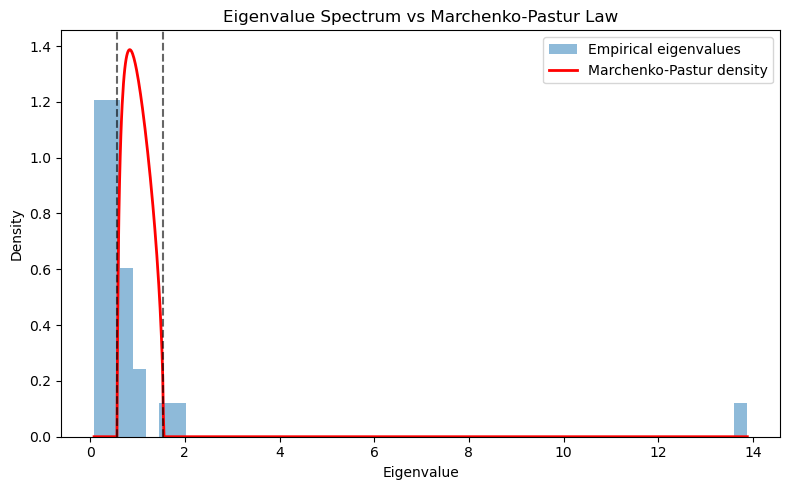

In [33]:
# calculate corr matrix and eigenvalues and cleaned cov matrix

vols = df_cov.std().values
D = np.diag(vols)

corr_matrix = df_cov.corr()
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)

N = len(df_cov.columns)
T = df_cov.shape[0]

a = (1 - np.sqrt(N/T))**2
b = (1 + np.sqrt(N/T))**2
x = np.linspace(eigenvalues.min(), eigenvalues.max(), 1000)
density = np.zeros_like(x)
mask = (x >= a) & (x <= b)

density[mask] = (np.sqrt((b - x[mask]) * (x[mask] - a)) / (2 * np.pi * (N/T) * x[mask]))
mp = density

plt.figure(figsize=(8, 5))
plt.hist(eigenvalues, bins=50, density=True, alpha=0.5, label="Empirical eigenvalues")
plt.plot(x, mp, 'r', lw=2, label="Marchenko-Pastur density")
plt.axvline(a, color='k', linestyle='--', alpha=0.6)
plt.axvline(b, color='k', linestyle='--', alpha=0.6)
plt.title("Eigenvalue Spectrum vs Marchenko-Pastur Law")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# since marchenko pastur law for cleaning is done on corr matrix
# var is assumed to be 1, so max eigen value that is noise is (1 + n/t) ^2
max_eigen = (1 + np.sqrt(N / T)) ** 2

noise_eigen = eigenvalues <= max_eigen
cleaned_eigenvalues = eigenvalues.copy()
cleaned_eigenvalues[noise_eigen] = np.mean(eigenvalues[noise_eigen])

clean_corr_matrix = eigenvectors @ np.diag(cleaned_eigenvalues) @ eigenvectors.T

# we need diag of corr matrix to be all 1s (corr with itself is 1), so we need to slightly modify the diag
diag = np.diag(clean_corr_matrix)
clean_corr_matrix = clean_corr_matrix / np.sqrt(np.outer(diag,diag))
# diag of corr is back to being one

# to go from cor to cov matrix, we multiply by the vol (std) of returns of each stock
# we calulcated this with the D before
clean_cov_matrix = D @ clean_corr_matrix @ D

# cov matrix is calculated with daily returns, so needs to be converted to monthly covariance, approx 21 trading days
clean_cov_matrix_monthly = clean_cov_matrix * 21




In [34]:
# now the equilibrium returns is needed, black litterman optimisation starts by assuming the current market is in perfect equilibrium
# the equilibrium returns vector is the vector of returns the stocks should have so that any rational investor would buy as is currently
# neutral estimation of returns
# it acts as the "prior" in black litterman, almost like in bayesion stats

# usually a reference portfolio is used, or percentage of the market for each company is used as the weights
# and with this plus the CAPM (capital asses pricing model), which states that the market is already in optimal equilibrium
# so if we know the "weights" of the markets portfolio, we can figure out what the market is "expecting" as returns, and thats the prior

# since that data can be hard to acquire for a historic data and for pragmatic reasons, assume prior as a equally weighted portfolio of the 30 stocks
# in the universe, with weights 1/30

market_weights = np.ones(N) / N

# assume industry standard delta of 2.5, coefficient of risk aversion, calculated as the market returns - the risk free rate / annual variance
delta = 2.5

# equilibrium returns
pi = delta * clean_corr_matrix @ market_weights

In [35]:
# map z scores unto real returs, as the "visions" matrix needs to be expressed in real returns units not z scores
# z scores get multiplied by the volatility of that stock, that way my "visions" vector is simply expressing std deviations against the market equilibrium
# model is seeing how much above or below the equilibrium or the prior are the returns for this stock going to be

# first take daily vol and convert into monthly vol 
monthly_vols = vols * np.sqrt(21)

# now create visions vector Q
results["Q"] = results["Z Score"] * monthly_vols 

In [36]:
# we now have our predictions turned into z scores, we have our rolling IC, we have cleaned monthly covariance matrix (Sigma)
# we have Pi matrix or equilibrium matrix and we have our visions vector Q

# the only thing missing is omega or the uncertainty matrix, says how confident we are in predictions made by models
# or whether to trust more in market equilibrium
# omega = diag(P*sigma*PT) * ((1-cf)/cf)

# our models predict stock performance independently, not stock a will beat stock b so P is the identity matrix as our predictions have no correlations
P = np.eye(30)

# confidence muktiplier based on the rolling 6 month IR -> ICIR
conf_mult = (1 - confidence_factor) / confidence_factor

# we want only the variance of each stock, so we take the diagonal of the covariance matrix
diag_cov = np.diag(clean_cov_matrix_monthly)
Omega = diag_cov * conf_mult

In [37]:
# now we have all parts to black litterman optim
# takes market equilibrium or prior and adjusts it towards where models are predicting, with an "agressiveness" factor depending on accuracy of models
# E[R] = pi (prior) + tau * cov * PT * (P*tau*cov*pT + omega)^-1 * (Q - P*pi)
# this final term: (Q - P*pi) is the diff between what models are predicting and what market equilibrium is pricing in as expected returns
# sees what new information are models predicting, if it predicts same movement as market equilibrium expects, no new information
# tau * cov * PT * (P*tau*cov*pT + omega)^-1 is the kalman gain, decides whether to place more weight on prior or on predictions
# tau scales down the cov matrix, which says we have more confidence in past market risk and equilibrium then in future returns
# omega gives the confidence in our views or predictions for future returns
# the larger omega is, the more uncertain we are, so when we inverse it will be near 0, so the multiplication with the final term will be near 0
# we stay near equilibrium
# if omega is small, expected returns moves towards our predictions and away from equilibrium

# there is not set value or standard for tau, one paper, michaud 1998 set as a simple rule something like
# tau = approx 1 / t(data), so in this case 1/504, which is approx 0.002, but since we move into monthly preds, multiply by 21
# approx 0.042, but we wan't to have a bit more confidence in prior, want models to "have to really work to prove themselves"
tau = 0.025

tau_sigma = tau * clean_cov_matrix_monthly
deviation = results["Q"].to_numpy() - (P @ pi)
kalman_gain = tau_sigma @ P.T @ np.linalg.inv(((P @ tau_sigma @ P.T) + Omega))
results["Expected Returns"] = pi + (kalman_gain @ deviation)

In [38]:
# move onto markowiitz optimisation with restrictions
# maximize: wT * E[R] - 1/2 * gamma * wT * sigma * w
# wt * E[R] is the expected return of the portfolio built
# wt * cov matrix(sigma) * w is the variance or risk of the portfolio built
# this is multiplied by gamma, which is the aversion to risk
# the 1/2 is just for derivatives, makes it simpler

# in order to stabilize the weights, eg. not 100% of portfolio on the best performer, restrictions are added
# fully invested, so sum of abs(w) is 2, 100% on longs 100% on shorts
# academic setting so we assume risk and interest free borrowing etc.
# market neutral portfolio, so sum of w is 0
# concentration limits, no stock can occupy more then 10%, a equi balanced portfolio would be 1/30, 3.33%, so we allow a max of 3x weight onto one stock
# gamma is 2.5, we keep it the same as in equilibrium calculation, consisten investor pyschology

mu = results["Expected Returns"].to_numpy()
gamma = 2.5
sigma = clean_cov_matrix_monthly

weights = cp.Variable(30)
risk = cp.quad_form(weights,sigma)
returns = mu @ weights

objective = cp.Maximize(returns - ((1/2) * gamma * risk))
constraints = [weights >= -0.1, weights <= 0.1, cp.sum(weights) == 0, cp.norm1(weights) <= 2] # not equal to 2 as that would break optimizer
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.ECOS)

results["Portfolio Weights"] = weights.value
for ticker, value in zip(results["Ticker"], results["Portfolio Weights"]):
    print(f"{ticker}: {value}")


MSFT: 0.09999999999842447
VZ: -0.0999999997645073
LIN: -0.09999999998202808
MS: 0.09999999999957401
BAC: -0.0999999999987709
NVDA: 0.09999999987673319
JNJ: -0.09999999999828663
AVGO: -0.09999999996096329
ORCL: -8.103871352263824e-12
BA: 0.09999999999911996
NEE: -0.0999999999989323
AMZN: -0.09999999999228729
UNH: 0.09999999998885006
UPS: -2.291878254902483e-11
MCD: -1.5728989109093692e-11
HD: 0.09999999998860769
GS: -0.09999999999306673
MRK: -2.246951435724401e-12
NKE: 0.09999999998275322
SHW: -4.05746336642197e-12
CMCSA: -1.2423005356552518e-14
AAPL: 1.6403041859168685e-13
GOOG: -2.0263770008403035e-11
MMM: -7.875347179814821e-11
PFE: -0.09999999999357453
JPM: 0.0525497701133233
XOM: -0.0999999999625473
CAT: 0.047450229905573495
SLB: 0.09999999995440711
CVX: 0.09999999998951703


## Complete Summary of Portfolio Construction

This notebook turns model forecasts into an investable long-short portfolio by combining expected returns, covariance information, and portfolio constraints.

### Workflow Summary

- A model is trained on the transformed feature dataset.
- Next-month stock predictions are ranked and converted into probability-based Z-scores.
- Those scores are used as Black-Litterman views to update the prior equilibrium returns.
- A constrained Markowitz optimization is solved to produce the final portfolio weights.

### Main Outcome

The final result is a market-neutral, weight-limited portfolio that blends statistical forecasts with covariance-aware allocation.

---